## Data Cleaning

In [127]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [128]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [129]:
df.shape

(400, 5)

In [130]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
User ID            400 non-null int64
Gender             400 non-null object
Age                400 non-null int64
EstimatedSalary    400 non-null int64
Purchased          400 non-null int64
dtypes: int64(4), object(1)
memory usage: 14.1+ KB


In [132]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [133]:
df.describe(include = "object")

,Gender
count,400
unique,2
top,Female
freq,204


# missing vaules

In [134]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [135]:
missing_percent = (df.isnull().sum() / len(df))
missing_percent

User ID            0.0
Gender             0.0
Age                0.0
EstimatedSalary    0.0
Purchased          0.0
dtype: float64

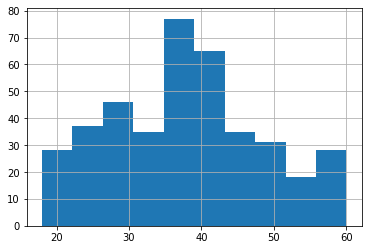

In [136]:
df["Age"].hist()

In [137]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [138]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()

KeyError: 'Embarked'

In [139]:
df.drop(columns="Cabin", inplace = True)
df.isnull().sum()

KeyError: "['Cabin'] not found in axis"

In [93]:
#Duplicate Data

In [140]:
df.duplicated().sum()

0

In [141]:
df = df.drop_duplicated()

AttributeError: 'DataFrame' object has no attribute 'drop_duplicated'

In [96]:
#Data Types Cleaning

In [142]:
df.dtypes

User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

In [143]:
df["Sex"].unique()

KeyError: 'Sex'

In [144]:
df["Sex"] = df["Sex"].str.lower()

KeyError: 'Sex'

In [100]:
df["Embarked"] = df["Embarked"].str.strip()

In [101]:
# USed Bocplot FOR Outliers

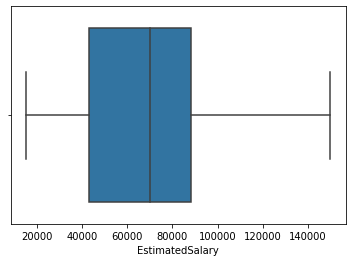

In [148]:
sns.boxplot(df["EstimatedSalary"])

In [149]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

KeyError: 'Fare'

In [154]:
outliers = df[(df["EstimatedSalary"] < lower) | (df["EstimatedSalary"] > upper)]
outliers

,User ID,Gender,Age,EstimatedSalary,Purchased


In [155]:
#Remove Outliers

df = df[(df["EstimatedSalary"] >= lower) & (df["EstimatedSalary"] <= upper)]
df

,User ID,Gender,Age,EstimatedSalary,Purchased


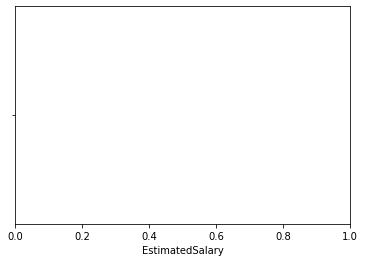

In [157]:
sns.boxplot(df["EstimatedSalary"])

In [153]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased


In [119]:
df["Survived"].value_counts()

0    504
1    241
Name: Survived, dtype: int64

In [120]:
df["PassengerId"].value_counts()

891    1
285    1
296    1
295    1
294    1
293    1
290    1
289    1
288    1
287    1
286    1
284    1
272    1
283    1
282    1
281    1
280    1
279    1
278    1
277    1
275    1
274    1
297    1
299    1
301    1
302    1
332    1
331    1
329    1
328    1
      ..
567    1
566    1
565    1
564    1
563    1
562    1
583    1
585    1
611    1
587    1
609    1
608    1
607    1
606    1
605    1
604    1
603    1
602    1
601    1
599    1
598    1
597    1
596    1
595    1
594    1
593    1
591    1
590    1
589    1
1      1
Name: PassengerId, Length: 745, dtype: int64

In [122]:
df.isnull().sum()
df.dtypes
df.shape
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000,745.000000
mean,445.481879,0.323490,2.518121,28.543960,0.434899,0.339597,16.231946
std,259.765268,0.468122,0.703300,12.775732,0.912203,0.792337,11.222845
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,215.000000,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,449.000000,0.000000,3.000000,28.000000,0.000000,0.000000,11.500000
75%,669.000000,1.000000,3.000000,34.000000,1.000000,0.000000,25.466700
max,891.000000,1.000000,3.000000,80.000000,5.000000,6.000000,52.554200


In [125]:
#save data to new file

df.to_csv("titanic_data_cleaned.csv", index = False)

In [126]:
# reusable data quality report function

def data_quality_report(df):
    report = {
        "shape" : df.shape,
        "missing_values" : df.isnull().sum(),
        "duplicate_count" : int(df.duplicated().sum()),
        "data types" : df.types.astype(str).to_dict()
    }
